In [1]:
from pathlib import Path
from shutil import rmtree
from math import ceil
from json import dumps
from typing import Literal
from collections import defaultdict
from pickle import Pickler
from gzip import open as gz_open
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.utils.class_weight import compute_sample_weight


RANDOM_STATE = 12345

# Data

In [ ]:
def prepare_experiment(
    which: Literal["full", "iot", "control", "infra"],
    target: Literal["binary", "grouped", "all"],
    overwrite: bool = False,
):
    experiment = {}
    dataset_path = Path("../datasense/dataset/")
    for split in ["train", "test"]:
        split_data = dataset_path / f"datasense_{which}_{split}_1sec.parquet"
        split_data = pd.read_parquet(split_data)
        if target == "binary":
            y_split = split_data["label1"]
        elif target == "grouped":
            y_split = split_data["label2"]
        else:
            y_split = split_data["label4"]
        experiment[split] = (split_data, y_split)
    experiment["sample_weight"] = compute_sample_weight(
        class_weight="balanced",
        y=experiment["train"][0]["label_extended"],
    )
    if which == "full":
        experiment["transformers"] = make_column_transformer(
            ("drop", ["device_name"]),
            ("drop", make_column_selector(r"^label")),
            (OneHotEncoder(sparse_output=False), ["device_type"]),
            remainder="passthrough",
            verbose_feature_names_out=False,
        )
    else:
        experiment["transformers"] = make_column_transformer(
            ("drop", ["device_name", "device_type"]),
            ("drop", make_column_selector(r"^label")),
            remainder="passthrough",
            verbose_feature_names_out=False,
        )
    results_dir = Path("results")
    results_dir /= f"decision_tree_{which}_{target}"
    if results_dir.is_dir():
        if overwrite:
            rmtree(results_dir, ignore_errors=True)
        else:
            raise RuntimeError("Experiment already executed and overwrite set to False")
    results_dir.mkdir(exist_ok=True, parents=True)
    cache_dir = results_dir / ".cache"
    cache_dir.mkdir()
    experiment["results_dir"] = results_dir
    experiment["cache_dir"] = str(cache_dir)
    return experiment

In [3]:
experiment = prepare_experiment(which="full", target="binary", overwrite=True)

X_train, y_train = experiment["train"]
sample_weight = experiment["sample_weight"]
X_test, y_test = experiment["test"]
results_dir = experiment["results_dir"]
cache_dir = experiment["cache_dir"]

# Experiment

## Training pipe

In [4]:
train_pipe = Pipeline(
    steps=[
        ("transformer", experiment["transformers"]),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ],
    memory=cache_dir,
    verbose=False,
)

## Grid seach cross-validation

In [5]:
param_grid = {
    "model__criterion": ["gini", "entropy"],
    # `min_samples_leaf` : offer a bit more of regularization for the training
    "model__min_samples_leaf": [3, 5, 7],
    # `max_depth`      : is too restrictive a measure of complexity
    # `max_leaf_nodes` : represents the level of partitioning of the training data
    # `max_leaf_nodes` : too many partitions can mean overfitting
    "model__max_leaf_nodes": [800, 1600, 3200, None],
}

In [6]:
grid = GridSearchCV(
    estimator=train_pipe,
    param_grid=param_grid,
    scoring=["balanced_accuracy", "f1_macro"],
    n_jobs=3,
    refit="f1_macro",
    cv=4,
    verbose=3,
    return_train_score=True,
)

grid.fit(X_train, y_train, model__sample_weight=sample_weight)

trained_pipe = grid.best_estimator_
trained_model = trained_pipe["model"]
trained_tree = trained_model.tree_

Fitting 4 folds for each of 24 candidates, totalling 96 fits
[CV 2/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=3; balanced_accuracy: (train=0.713, test=0.702) f1_macro: (train=0.647, test=0.637) total time=   6.1s
[CV 1/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=3; balanced_accuracy: (train=0.713, test=0.700) f1_macro: (train=0.647, test=0.634) total time=   6.2s
[CV 3/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=3; balanced_accuracy: (train=0.713, test=0.701) f1_macro: (train=0.647, test=0.636) total time=   6.3s
[CV 2/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=5; balanced_accuracy: (train=0.713, test=0.701) f1_macro: (train=0.647, test=0.636) total time=   4.2s
[CV 1/4] END model__criterion=gini, model__max_leaf_nodes=800, model__min_samples_leaf=5; balanced_accuracy: (train=0.713, test=0.699) f1_macro: (train=0.648, test=0.634) total ti

## Cross-validation results

In [7]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results.sort_values(by="rank_test_f1_macro", inplace=True)
cv_results.to_csv(results_dir / "train_cv_results.csv", index=False)

## Feature importance

In [8]:
feature_names = trained_pipe["transformer"].get_feature_names_out()

feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_pipe["model"].feature_importances_,
})
feature_importances.sort_values(
    by="importance", ascending=False,
    ignore_index=True, inplace=True,
)
feature_importances.to_csv(results_dir / "feature_importances.csv", index=False)

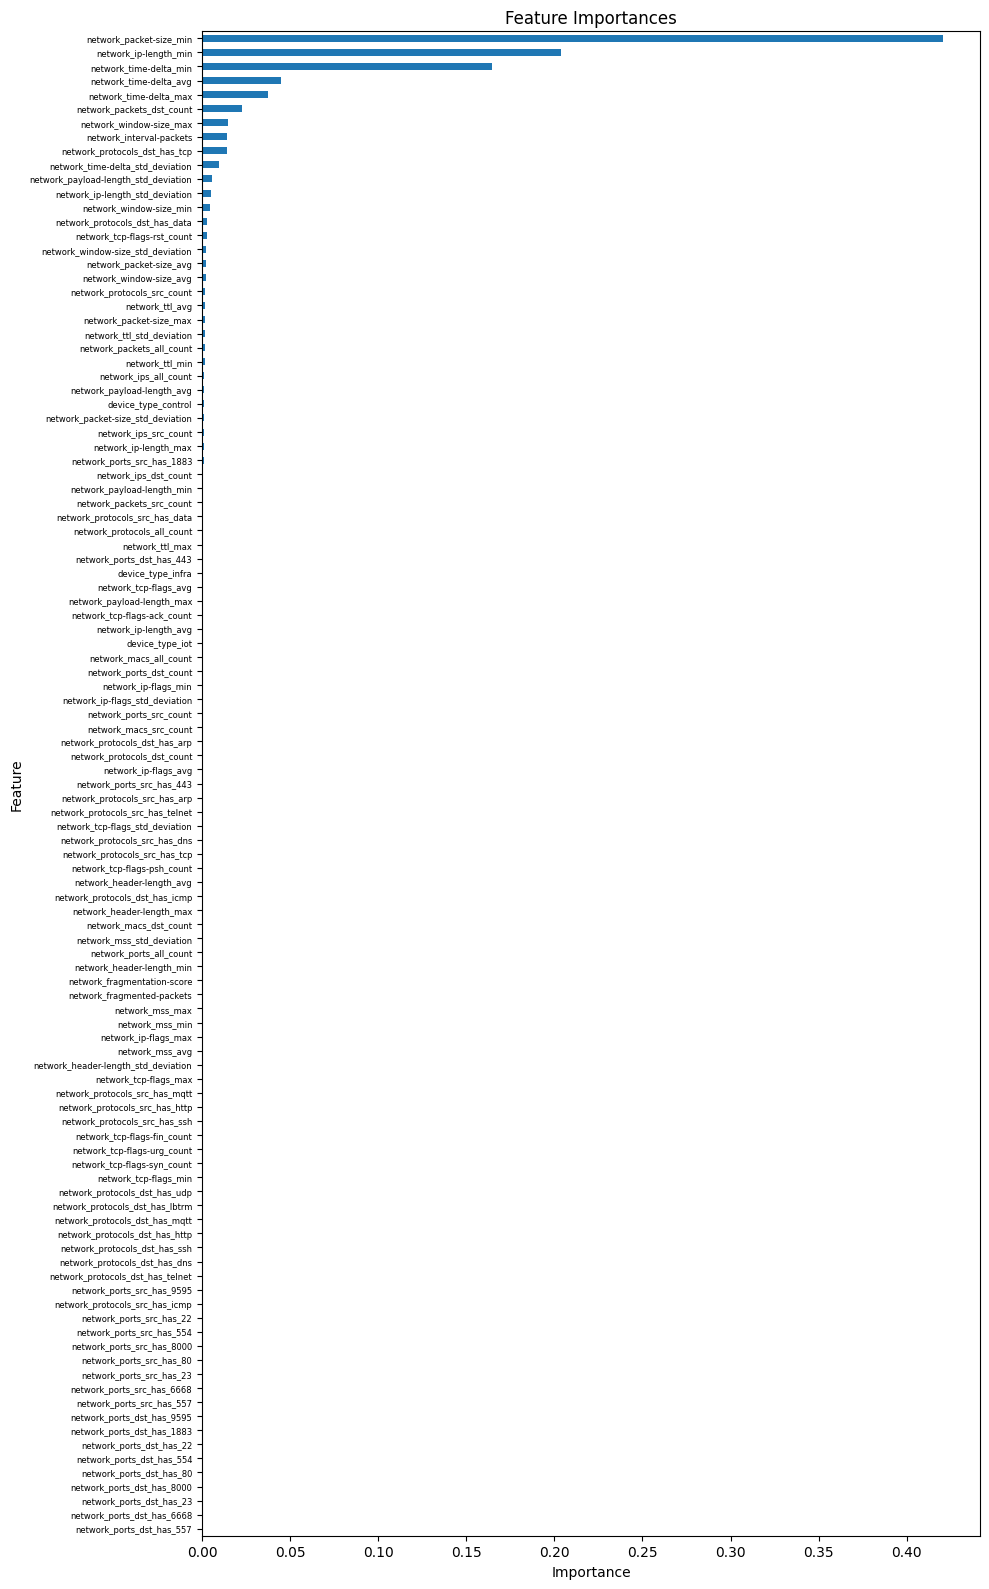

In [9]:
fig, ax = plt.subplots(figsize=(10, 16))

feature_importances["importance"].plot(kind="barh", ax=ax)

ax.invert_yaxis()
ax.set_yticks(
    ticks=range(feature_importances.shape[0]),
    labels=feature_importances["feature"],
    fontsize=6,
)
ax.set_title("Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(results_dir / "feature_importances.png", dpi=300)
plt.show()

# Model evaluations

## Train-split evaluations

In [10]:
y_proba = trained_pipe.predict_proba(X_train)

train_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

train_results.to_parquet(
    results_dir / "train_predict_proba.parquet",
    index=False,
    compression="gzip",
)

## Test-split evaluations

In [11]:
y_proba = trained_pipe.predict_proba(X_test)

test_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

test_results.to_parquet(
    results_dir / "test_predict_proba.parquet",
    index=False,
    compression="gzip",
)

# Model summary and persistency

## Model persistency

In [12]:
pipe_persist_path = results_dir / "pipe.pickle.gz"

with gz_open(pipe_persist_path, mode="wb") as pf:
    Pickler(pf, protocol=5).dump(trained_pipe)

## Model summary

In [13]:
model_summary = {
    "best_parameters": grid.best_params_,
    "all_parameters": trained_model.get_params(),
    "tree_structure": {
        "n_nodes": int(trained_tree.node_count),
        "n_leafs": int(trained_tree.n_leaves),
        "max_depth": int(trained_tree.max_depth),
    }
}

model_summary = dumps(model_summary, indent=2)
(results_dir / "model_summary.json").write_text(model_summary)
print("MODEL SUMMARY:", model_summary, sep="\n")

MODEL SUMMARY:
{
  "best_parameters": {
    "model__criterion": "entropy",
    "model__max_leaf_nodes": 3200,
    "model__min_samples_leaf": 3
  },
  "all_parameters": {
    "ccp_alpha": 0.0,
    "class_weight": null,
    "criterion": "entropy",
    "max_depth": null,
    "max_features": null,
    "max_leaf_nodes": 3200,
    "min_impurity_decrease": 0.0,
    "min_samples_leaf": 3,
    "min_samples_split": 2,
    "min_weight_fraction_leaf": 0.0,
    "monotonic_cst": null,
    "random_state": 12345,
    "splitter": "best"
  },
  "tree_structure": {
    "n_nodes": 5609,
    "n_leafs": 2805,
    "max_depth": 69
  }
}
